K means Clustering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs #used to generate synthetic datasets for clustering
from sklearn.preprocessing import StandardScaler

In [2]:
X,y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=0)

In [5]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [6]:
df

,Feature_1,Feature_2
0,1.052417,4.544981
1,-1.770469,3.352503
2,-1.831415,2.286754
3,1.360349,3.333614
4,-0.185498,4.417054
...,...,...
495,2.418340,1.434997
496,2.547461,1.713633
497,2.518111,1.515327
498,0.333819,4.936458


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [11]:
#Finding the optimal number of clusters using the elbow method
inertia = []
K_range = range(1, 11) # the range of K values to test

In [ ]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42) #kmeans clustering algorithm with k clusters
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

In [14]:
inertia

[1000.0000000000002,
 404.1814840803352,
 138.48971856185543,
 120.0329614532852,
 111.38422447852841,
 95.4362513145374,
 83.62787134261356,
 70.26414440662822,
 58.906179766446414,
 56.11013453595797]

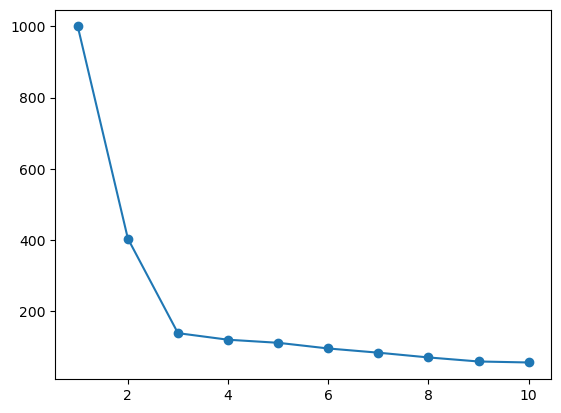

In [16]:
plt.plot(K_range, inertia, marker='o')

In [ ]:
#Final clustering with the optimal number of clusters
kmeans_final = KMeans(n_clusters=3, random_state=42) #now k = 3, as we know the optimal number of clusters is 3
kmeans_final

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [34]:
#labels for each point in the dataset
cluster_labels = kmeans_final.fit_predict(X_scaled)


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [ ]:
df['cluster'] = cluster_labels #create a new column in the DataFrame to store the cluster labels

In [31]:
df

,Feature_1,Feature_2,cluster
0,1.052417,4.544981,2
1,-1.770469,3.352503,1
2,-1.831415,2.286754,1
3,1.360349,3.333614,2
4,-0.185498,4.417054,2
...,...,...,...
495,2.418340,1.434997,0
496,2.547461,1.713633,0
497,2.518111,1.515327,0
498,0.333819,4.936458,2


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

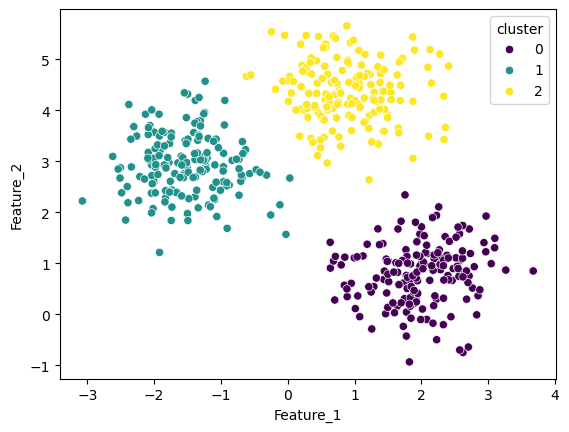

In [ ]:

sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['cluster'], palette='viridis') 